# Train and evaluate the intent-routing SVM

This notebook trains the first OpsFlow intent router using word TF-IDF and a calibrated linear support-vector classifier. It keeps a deterministic, stratified 20% test set untouched during model and threshold selection.

The evaluation covers multiclass quality, confidence calibration, routing safety, error inspection, and influential features. The saved artifact is the exact pipeline evaluated on the held-out test set; it is **not** retrained on the test rows.

## 1. Imports and reproducibility controls

In [1]:
from __future__ import annotations

import hashlib
import json
import platform
from importlib.metadata import version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    log_loss,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

SEED = 20261004
EXPECTED_DATASET_SHA256 = '6ef925721995fc38edbee2a95cdff45a463dabc2bf0773409dab187d8f4030a0'
EXPECTED_LABELS = [
    'compound_request',
    'email_drafting',
    'faq_retrieval',
    'keyword_extraction',
    'out_of_scope',
    'reminder_creation',
    'sentiment_analysis',
    'summarization',
]
DIRECT_LABELS = {'sentiment_analysis', 'keyword_extraction', 'faq_retrieval'}
CRITICAL_AGENT_LABELS = {'reminder_creation', 'compound_request'}

working_directory = Path.cwd().resolve()
REPO_ROOT = next(
    candidate
    for candidate in (working_directory, *working_directory.parents)
    if (candidate / 'data' / 'tasks_benchmark.csv').exists()
)
DATA_PATH = REPO_ROOT / 'data' / 'tasks_benchmark.csv'
MODEL_DIR = REPO_ROOT / 'artifacts' / 'models'
MODEL_PATH = MODEL_DIR / 'intent_router_svm.joblib'
METADATA_PATH = MODEL_DIR / 'intent_router_svm_metadata.json'

pd.set_option('display.max_colwidth', 120)
print(f'Repository: {REPO_ROOT}')
print(f'Python: {platform.python_version()}')
print(f'scikit-learn: {version("scikit-learn")}')

Repository: /Users/orbin/Documents/GitHub/opsflow-agent
Python: 3.12.13
scikit-learn: 1.9.1


## 2. Load and validate the reviewed dataset

The fingerprint assertion prevents silently training on data other than the reviewed CSV.

In [2]:
dataset_bytes = DATA_PATH.read_bytes()
dataset_sha256 = hashlib.sha256(dataset_bytes).hexdigest()
assert dataset_sha256 == EXPECTED_DATASET_SHA256, (
    'Dataset fingerprint changed; review the new data before training.'
)

dataset = pd.read_csv(DATA_PATH)
assert list(dataset.columns) == ['text', 'label']
assert len(dataset) == 1_000
assert not dataset.isna().any().any()
assert not dataset['text'].str.strip().eq('').any()
assert sorted(dataset['label'].unique()) == EXPECTED_LABELS
assert dataset['text'].duplicated().sum() == 0
assert dataset['label'].value_counts().eq(125).all()

dataset = dataset.reset_index(names='row_id')
label_counts = dataset['label'].value_counts().sort_index().rename('count')
display(label_counts.to_frame())
print(f'Dataset SHA-256: {dataset_sha256}')

,count
label,
compound_request,125
email_drafting,125
faq_retrieval,125
keyword_extraction,125
out_of_scope,125
reminder_creation,125
sentiment_analysis,125
summarization,125


Dataset SHA-256: 6ef925721995fc38edbee2a95cdff45a463dabc2bf0773409dab187d8f4030a0


,min,median,max,mean
label,,,,
compound_request,13,20.0,30,20.7
email_drafting,10,15.0,31,15.3
faq_retrieval,8,12.0,18,11.7
keyword_extraction,5,18.0,23,18.1
out_of_scope,2,8.0,15,7.9
reminder_creation,8,13.0,21,12.6
sentiment_analysis,4,14.0,20,14.2
summarization,20,28.0,38,28.1


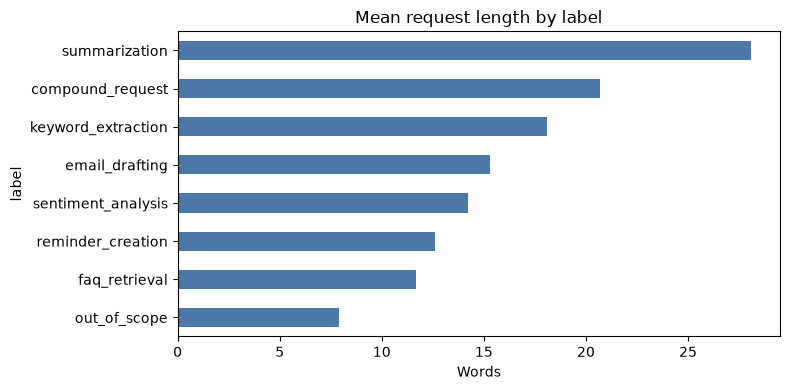

In [3]:
length_summary = (
    dataset.assign(word_count=dataset['text'].str.split().str.len())
    .groupby('label')['word_count']
    .agg(['min', 'median', 'max', 'mean'])
    .round(1)
)
display(length_summary)

ax = length_summary['mean'].sort_values().plot.barh(figsize=(8, 4), color='#4c78a8')
ax.set_title('Mean request length by label')
ax.set_xlabel('Words')
plt.tight_layout()
plt.show()

## 3. Create the untouched stratified test set

The split keeps 100 development and 25 test examples for every label. Only the development partition is used for hyperparameter and routing-threshold selection.

In [4]:
development, test = train_test_split(
    dataset,
    test_size=0.20,
    random_state=SEED,
    stratify=dataset['label'],
)

assert set(development['row_id']).isdisjoint(test['row_id'])
assert development['label'].value_counts().eq(100).all()
assert test['label'].value_counts().eq(25).all()

X_development = development['text']
y_development = development['label']
X_test = test['text']
y_test = test['label']

split_counts = pd.concat(
    [
        development['label'].value_counts().sort_index().rename('development'),
        test['label'].value_counts().sort_index().rename('test'),
    ],
    axis=1,
)
display(split_counts)

,development,test
label,,
compound_request,100,25
email_drafting,100,25
faq_retrieval,100,25
keyword_extraction,100,25
out_of_scope,100,25
reminder_creation,100,25
sentiment_analysis,100,25
summarization,100,25


## 4. Select a small TF-IDF + calibrated LinearSVC configuration

The search is intentionally narrow: word unigrams versus unigram/bigrams and three regularization strengths. TF-IDF is fitted inside every outer fold, preventing vocabulary and IDF leakage from validation rows. Calibration uses sigmoid scaling in five inner folds. Macro F1 is the selection metric because every intent matters.

In [5]:
calibration_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
selection_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 1)

pipeline = Pipeline(
    steps=[
        (
            'tfidf',
            TfidfVectorizer(
                lowercase=True,
                strip_accents='unicode',
                sublinear_tf=True,
            ),
        ),
        (
            'classifier',
            CalibratedClassifierCV(
                estimator=LinearSVC(random_state=SEED),
                method='sigmoid',
                cv=calibration_cv,
            ),
        ),
    ]
)

parameter_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'classifier__estimator__C': [0.5, 1.0, 2.0],
}

search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring={'macro_f1': 'f1_macro', 'accuracy': 'accuracy'},
    refit='macro_f1',
    cv=selection_cv,
    n_jobs=-1,
    return_train_score=False,
)
search.fit(X_development, y_development)
best_model = search.best_estimator_

cv_results = (
    pd.DataFrame(search.cv_results_)[
        [
            'param_tfidf__ngram_range',
            'param_classifier__estimator__C',
            'mean_test_macro_f1',
            'std_test_macro_f1',
            'mean_test_accuracy',
            'rank_test_macro_f1',
        ]
    ]
    .sort_values('rank_test_macro_f1')
    .reset_index(drop=True)
)
display(cv_results.round(4))
print(f'Best parameters: {search.best_params_}')
print(f'Best cross-validated macro F1: {search.best_score_:.4f}')

,param_tfidf__ngram_range,param_classifier__estimator__C,mean_test_macro_f1,std_test_macro_f1,mean_test_accuracy,rank_test_macro_f1
0,"(1, 1)",1.0,0.8361,0.0131,0.8412,1
1,"(1, 1)",2.0,0.8332,0.0209,0.8387,2
2,"(1, 1)",0.5,0.8318,0.0145,0.8375,3
3,"(1, 2)",2.0,0.8270,0.0307,0.8338,4
4,"(1, 2)",1.0,0.8239,0.0329,0.8312,5
5,"(1, 2)",0.5,0.8197,0.0369,0.8275,6


Best parameters: {'classifier__estimator__C': 1.0, 'tfidf__ngram_range': (1, 1)}
Best cross-validated macro F1: 0.8361


In [6]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_development, y_development)
dummy_predictions = dummy.predict(X_test)
dummy_metrics = {
    'accuracy': accuracy_score(y_test, dummy_predictions),
    'macro_f1': f1_score(y_test, dummy_predictions, average='macro'),
}
pd.Series(dummy_metrics, name='most_frequent_dummy').round(4)

accuracy    0.1250
macro_f1    0.0278
Name: most_frequent_dummy, dtype: float64

## 5. Choose a direct-routing threshold without using the test set

Out-of-fold development probabilities simulate unseen predictions while leaving the test partition untouched. A threshold is eligible only when direct-label precision is at least 98%, no reminder or compound request is falsely accepted for direct execution, at least 30 requests are accepted overall, and at least 10 are accepted for each direct label. Among eligible thresholds, the lowest threshold provides the greatest coverage.

In [7]:
threshold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 2)
development_probabilities = cross_val_predict(
    clone(best_model),
    X_development,
    y_development,
    cv=threshold_cv,
    method='predict_proba',
    n_jobs=-1,
)
classes = np.asarray(best_model.classes_)
development_predictions = classes[development_probabilities.argmax(axis=1)]
development_confidence = development_probabilities.max(axis=1)


def routing_metrics(y_true, predictions, confidence, threshold):
    y_true_array = np.asarray(y_true)
    predictions_array = np.asarray(predictions)
    accepted = np.isin(predictions_array, list(DIRECT_LABELS)) & (confidence >= threshold)
    accepted_count = int(accepted.sum())
    correct_count = int((accepted & (predictions_array == y_true_array)).sum())
    agent_only_false_direct = accepted & ~np.isin(y_true_array, list(DIRECT_LABELS))
    critical_false_direct = accepted & np.isin(y_true_array, list(CRITICAL_AGENT_LABELS))
    accepted_per_label = {
        label: int((accepted & (predictions_array == label)).sum())
        for label in sorted(DIRECT_LABELS)
    }
    return {
        'threshold': float(threshold),
        'accepted_count': accepted_count,
        'coverage': accepted_count / len(y_true_array),
        'direct_precision': correct_count / accepted_count if accepted_count else np.nan,
        'agent_only_false_direct_count': int(agent_only_false_direct.sum()),
        'critical_false_direct_count': int(critical_false_direct.sum()),
        **{f'accepted_{label}': count for label, count in accepted_per_label.items()},
    }


thresholds = sorted(set(np.round(np.arange(0.50, 1.00, 0.01), 2)) | {0.85})
threshold_results = pd.DataFrame(
    routing_metrics(
        y_development,
        development_predictions,
        development_confidence,
        threshold,
    )
    for threshold in thresholds
)

minimum_per_direct_label = 10
eligible_thresholds = threshold_results[
    (threshold_results['direct_precision'] >= 0.98)
    & (threshold_results['critical_false_direct_count'] == 0)
    & (threshold_results['accepted_count'] >= 30)
    & (
        threshold_results[
            [f'accepted_{label}' for label in sorted(DIRECT_LABELS)]
        ].min(axis=1)
        >= minimum_per_direct_label
    )
]
selected_threshold = (
    float(eligible_thresholds.iloc[0]['threshold'])
    if not eligible_thresholds.empty
    else None
)

display(threshold_results[threshold_results['threshold'].isin([0.50, 0.70, 0.85, 0.90, 0.95, 0.99])].round(4))
print(f'Selected threshold: {selected_threshold}')

,threshold,accepted_count,coverage,direct_precision,agent_only_false_direct_count,critical_false_direct_count,accepted_faq_retrieval,accepted_keyword_extraction,accepted_sentiment_analysis
0,0.50,284,0.3550,0.9155,19,7,97,94,93
20,0.70,174,0.2175,0.9770,2,0,77,47,50
35,0.85,67,0.0838,1.0000,0,0,36,14,17
40,0.90,15,0.0188,1.0000,0,0,13,2,0
45,0.95,0,0.0000,NaN,0,0,0,0,0
49,0.99,0,0.0000,NaN,0,0,0,0,0


Selected threshold: 0.71


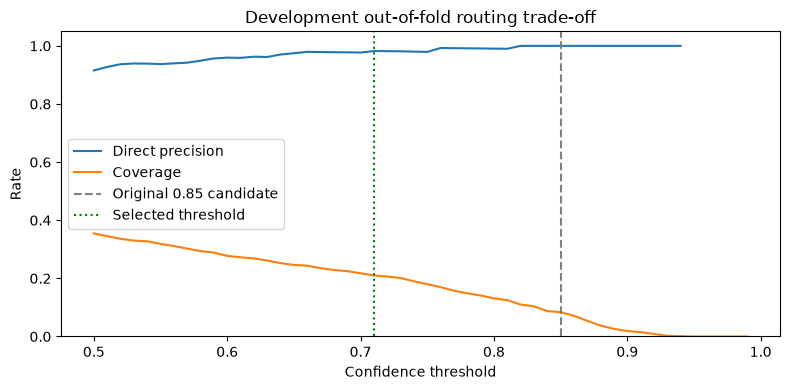

In [8]:
figure, axis = plt.subplots(figsize=(8, 4))
axis.plot(threshold_results['threshold'], threshold_results['direct_precision'], label='Direct precision')
axis.plot(threshold_results['threshold'], threshold_results['coverage'], label='Coverage')
axis.axvline(0.85, color='gray', linestyle='--', label='Original 0.85 candidate')
if selected_threshold is not None:
    axis.axvline(selected_threshold, color='green', linestyle=':', label='Selected threshold')
axis.set_ylim(0, 1.05)
axis.set_xlabel('Confidence threshold')
axis.set_ylabel('Rate')
axis.set_title('Development out-of-fold routing trade-off')
axis.legend(loc='best')
plt.tight_layout()
plt.show()

## 6. Evaluate once on the untouched test set

In [9]:
test_predictions = best_model.predict(X_test)
test_probabilities = best_model.predict_proba(X_test)
test_confidence = test_probabilities.max(axis=1)

assert np.allclose(test_probabilities.sum(axis=1), 1.0)
test_accuracy = accuracy_score(y_test, test_predictions)
test_macro_f1 = f1_score(y_test, test_predictions, average='macro')
test_weighted_f1 = f1_score(y_test, test_predictions, average='weighted')
test_report = classification_report(
    y_test,
    test_predictions,
    labels=classes,
    output_dict=True,
    zero_division=0,
)

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test macro F1: {test_macro_f1:.4f}')
print(f'Test weighted F1: {test_weighted_f1:.4f}')
display(pd.DataFrame(test_report).transpose().round(4))

Test accuracy: 0.8800
Test macro F1: 0.8813
Test weighted F1: 0.8813


,precision,recall,f1-score,support
compound_request,0.8800,0.88,0.8800,25.00
email_drafting,0.9583,0.92,0.9388,25.00
faq_retrieval,0.7241,0.84,0.7778,25.00
keyword_extraction,0.9583,0.92,0.9388,25.00
out_of_scope,0.7600,0.76,0.7600,25.00
reminder_creation,0.9600,0.96,0.9600,25.00
sentiment_analysis,0.9130,0.84,0.8750,25.00
summarization,0.9200,0.92,0.9200,25.00
accuracy,0.8800,0.88,0.8800,0.88
macro avg,0.8842,0.88,0.8813,200.00


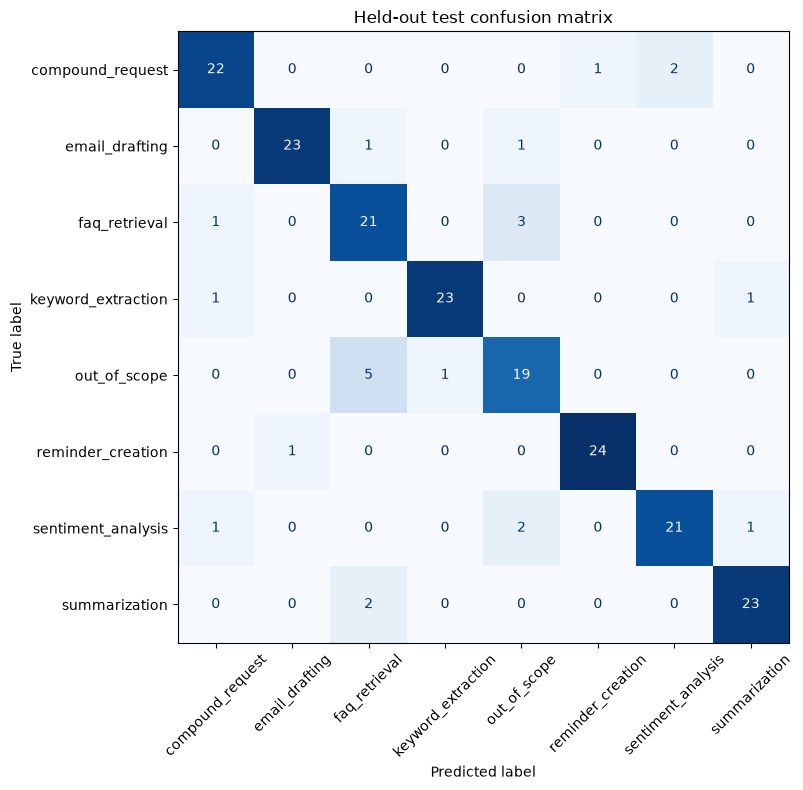

In [10]:
figure, axis = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=classes,
    xticks_rotation=45,
    cmap='Blues',
    colorbar=False,
    ax=axis,
)
axis.set_title('Held-out test confusion matrix')
plt.tight_layout()
plt.show()

### Confidence calibration

Log loss and multiclass Brier score assess the complete probability vector. Expected calibration error (ECE) compares top-label confidence with observed correctness in fixed-width bins. With only 200 test rows, these values are diagnostics rather than proof of production calibration.

In [11]:
def calibration_table(y_true, predictions, confidence, bin_count=10):
    frame = pd.DataFrame(
        {
            'confidence': confidence,
            'correct': np.asarray(y_true) == np.asarray(predictions),
        }
    )
    frame['bin'] = pd.cut(
        frame['confidence'],
        bins=np.linspace(0.0, 1.0, bin_count + 1),
        include_lowest=True,
    )
    return (
        frame.groupby('bin', observed=True)
        .agg(count=('correct', 'size'), accuracy=('correct', 'mean'), mean_confidence=('confidence', 'mean'))
        .reset_index()
    )


test_calibration = calibration_table(y_test, test_predictions, test_confidence)
test_ece = float(
    (
        test_calibration['count']
        / len(y_test)
        * (test_calibration['accuracy'] - test_calibration['mean_confidence']).abs()
    ).sum()
)
one_hot_test = (np.asarray(y_test)[:, None] == classes[None, :]).astype(float)
test_brier = float(np.mean(np.sum((test_probabilities - one_hot_test) ** 2, axis=1)))
test_log_loss = float(log_loss(y_test, test_probabilities, labels=classes))

display(test_calibration.round(4))
pd.Series(
    {'log_loss': test_log_loss, 'multiclass_brier_score': test_brier, 'top_label_ece': test_ece},
    name='test_calibration',
).round(4)

,bin,count,accuracy,mean_confidence
0,"(0.2, 0.3]",1,1.0000,0.2834
1,"(0.3, 0.4]",7,0.5714,0.3651
2,"(0.4, 0.5]",18,0.5000,0.4657
3,"(0.5, 0.6]",32,0.8125,0.5582
4,"(0.6, 0.7]",24,0.8333,0.6500
5,"(0.7, 0.8]",37,1.0000,0.7571
6,"(0.8, 0.9]",51,0.9608,0.8505
7,"(0.9, 1.0]",30,1.0000,0.9272


log_loss                  0.4549
multiclass_brier_score    0.2226
top_label_ece             0.1606
Name: test_calibration, dtype: float64

### Held-out routing policy

This reports the already-selected threshold on the test set. Test results do not alter the threshold.

In [12]:
policy_thresholds = [0.85]
if selected_threshold is not None and selected_threshold not in policy_thresholds:
    policy_thresholds.insert(0, selected_threshold)
test_routing_results = pd.DataFrame(
    routing_metrics(y_test, test_predictions, test_confidence, threshold)
    for threshold in policy_thresholds
)
display(test_routing_results.round(4))

,threshold,accepted_count,coverage,direct_precision,agent_only_false_direct_count,critical_false_direct_count,accepted_faq_retrieval,accepted_keyword_extraction,accepted_sentiment_analysis
0,0.71,47,0.235,1.0,0,0,18,14,15
1,0.85,18,0.090,1.0,0,0,12,3,3


## 7. Inspect errors and influential terms

These tables help detect reliance on synthetic wording or request length. Influential terms describe the SVM decision surface; they are not causal explanations.

In [13]:
error_review = test[['row_id', 'text', 'label']].copy()
error_review['prediction'] = test_predictions
error_review['confidence'] = test_confidence
error_review = (
    error_review[error_review['label'] != error_review['prediction']]
    .sort_values('confidence', ascending=False)
    .reset_index(drop=True)
)
print(f'Misclassified test examples: {len(error_review)} / {len(test)}')
display(error_review.head(25))

Misclassified test examples: 24 / 200


,row_id,text,label,prediction,confidence
0,423,Write to the facilities team about the flickering lights above the packing benches.,email_drafting,out_of_scope,0.857371
1,446,Explain the 'pending review' status as defined in the Mosslight user manual.,faq_retrieval,out_of_scope,0.800210
2,167,"Per the on-call runbook, who takes over if the primary engineer misses an alert?",faq_retrieval,out_of_scope,0.671528
3,553,"Shorten the supplied FAQ answer: You can download invoices from the billing page. Choose the month, then select Down...",summarization,faq_retrieval,0.657377
4,138,"Schedule a reminder at 08:30 Asia/Kolkata tomorrow to inspect the loading gate, and summarize 'Gate sticks halfway; ...",compound_request,reminder_creation,0.615146
5,605,Publish the finished blog post on our fictional company website.,out_of_scope,faq_retrieval,0.602106
6,606,"Per the continuity plan, which location is designated as the backup assembly point?",faq_retrieval,out_of_scope,0.597829
7,637,I need to write a thank-you email later; just remind me at five today.,reminder_creation,email_drafting,0.557604
8,822,How angry is this complaint: 'Charging twice and then blaming me is unacceptable'?,sentiment_analysis,compound_request,0.556267
9,84,Tell me the approved escalation route for a payroll discrepancy from the HR FAQ.,faq_retrieval,compound_request,0.547380


In [14]:
vectorizer = best_model.named_steps['tfidf']
calibrated_classifier = best_model.named_steps['classifier']
feature_names = vectorizer.get_feature_names_out()
fold_coefficients = np.stack(
    [fitted.estimator.coef_ for fitted in calibrated_classifier.calibrated_classifiers_]
)
mean_coefficients = fold_coefficients.mean(axis=0)

top_terms = {}
for class_index, label in enumerate(classes):
    strongest_indices = np.argsort(mean_coefficients[class_index])[-10:][::-1]
    top_terms[label] = feature_names[strongest_indices].tolist()

display(pd.DataFrame(top_terms))

,compound_request,email_drafting,faq_retrieval,keyword_extraction,out_of_scope,reminder_creation,sentiment_analysis,summarization
0,and,email,policy,phrases,degrees,reminder,attitude,recap
1,also,an,according,tags,why,remind,sentiment,this
2,summarize,that,does,this,calculate,to,does,condense
3,summary,compose,under,keywords,open,me,is,because
4,retrieve,prepare,handbook,topics,convert,nudge,how,the
5,draft,write,official,here,database,every,sound,short
6,then,we,faq,subjects,image,tomorrow,emotional,summarize
7,find,your,say,terms,approve,please,assess,brief
8,separately,wrong,our,content,fictional,next,positive,one
9,separate,without,guide,concepts,nearest,minutes,or,before


## 8. Save and reload the exact evaluated pipeline

Joblib artifacts are Python pickle-based. Load this model only from a trusted source. The companion JSON records provenance, evaluation, and the routing recommendation without requiring the binary artifact to be loaded.

In [15]:
def to_builtin(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {str(key): to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(item) for item in value]
    return value


MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, MODEL_PATH, compress=3)
model_sha256 = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()

selected_development_policy = (
    routing_metrics(
        y_development,
        development_predictions,
        development_confidence,
        selected_threshold,
    )
    if selected_threshold is not None
    else None
)
selected_test_policy = (
    routing_metrics(y_test, test_predictions, test_confidence, selected_threshold)
    if selected_threshold is not None
    else None
)
metadata = {
    'artifact_format_version': 1,
    'created_on': '2026-10-04',
    'model_artifact': MODEL_PATH.name,
    'model_sha256': model_sha256,
    'dataset': {
        'path': 'data/tasks_benchmark.csv',
        'sha256': dataset_sha256,
        'row_count': len(dataset),
        'labels': classes.tolist(),
    },
    'split': {
        'strategy': 'deterministic stratified 80/20 development/test',
        'random_state': SEED,
        'development_rows': len(development),
        'test_rows': len(test),
        'development_rows_per_label': 100,
        'test_rows_per_label': 25,
    },
    'pipeline': {
        'features': 'word TF-IDF',
        'classifier': 'sigmoid-calibrated LinearSVC',
        'calibration_folds': 5,
        'best_parameters': search.best_params_,
        'cross_validated_macro_f1': search.best_score_,
    },
    'routing_threshold': {
        'selected': selected_threshold,
        'original_candidate': 0.85,
        'selection_source': 'development-set out-of-fold probabilities',
        'criteria': {
            'minimum_direct_precision': 0.98,
            'maximum_critical_false_direct_count': 0,
            'minimum_accepted_total': 30,
            'minimum_accepted_per_direct_label': minimum_per_direct_label,
        },
        'development_metrics': selected_development_policy,
        'test_metrics': selected_test_policy,
    },
    'test_metrics': {
        'accuracy': test_accuracy,
        'macro_f1': test_macro_f1,
        'weighted_f1': test_weighted_f1,
        'log_loss': test_log_loss,
        'multiclass_brier_score': test_brier,
        'top_label_ece': test_ece,
        'per_label': {label: test_report[label] for label in classes},
    },
    'most_influential_terms': top_terms,
    'versions': {
        'python': platform.python_version(),
        'scikit-learn': version('scikit-learn'),
        'pandas': version('pandas'),
        'joblib': version('joblib'),
    },
}
METADATA_PATH.write_text(
    json.dumps(to_builtin(metadata), indent=2, sort_keys=True) + '\n',
    encoding='utf-8',
)

reloaded_model = joblib.load(MODEL_PATH)
assert np.array_equal(reloaded_model.predict(X_test), test_predictions)
np.testing.assert_allclose(
    reloaded_model.predict_proba(X_test),
    test_probabilities,
)

print(f'Saved model: {MODEL_PATH.relative_to(REPO_ROOT)}')
print(f'Saved metadata: {METADATA_PATH.relative_to(REPO_ROOT)}')
print(f'Model SHA-256: {model_sha256}')
print('Reload verification passed.')

Saved model: artifacts/models/intent_router_svm.joblib
Saved metadata: artifacts/models/intent_router_svm_metadata.json
Model SHA-256: 7407bb8ac6ca9b76cd3e75224f920c8e0da42cb55375561f745dcff5b8a2a44c
Reload verification passed.


## 9. Result summary and limitations

This test set is independent of fitting and selection, but it comes from the same synthetic generation process as the development rows. Results do not establish performance on real user traffic, company-specific FAQ wording, context-dependent follow-ups, or payload extraction. Those require later integration tests and a separately sourced challenge set.

In [16]:
summary = pd.Series(
    {
        'best_cv_macro_f1': search.best_score_,
        'test_accuracy': test_accuracy,
        'test_macro_f1': test_macro_f1,
        'test_log_loss': test_log_loss,
        'test_top_label_ece': test_ece,
        'selected_direct_routing_threshold': selected_threshold,
        'test_direct_precision_at_selected_threshold': (
            selected_test_policy['direct_precision']
            if selected_test_policy is not None
            else np.nan
        ),
        'test_direct_coverage_at_selected_threshold': (
            selected_test_policy['coverage']
            if selected_test_policy is not None
            else np.nan
        ),
        'test_critical_false_direct_count': (
            selected_test_policy['critical_false_direct_count']
            if selected_test_policy is not None
            else np.nan
        ),
    },
    name='result',
)
summary.round(4)

best_cv_macro_f1                               0.8361
test_accuracy                                  0.8800
test_macro_f1                                  0.8813
test_log_loss                                  0.4549
test_top_label_ece                             0.1606
selected_direct_routing_threshold              0.7100
test_direct_precision_at_selected_threshold    1.0000
test_direct_coverage_at_selected_threshold     0.2350
test_critical_false_direct_count               0.0000
Name: result, dtype: float64